#Import modules

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import os

#Insert file paths here

In [ ]:
file_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Cell_Reports_revisions_res'

#Load data

In [ ]:
metabolomics_pi3k = pd.read_csv(os.path.join(file_path, 'CPTAC_metabolites_ensemble_nn_predicted.csv'), index_col = 0).rename(columns = {'PIK3CA_mutation' : 'PI3K'})
metabolomics_pi3k[['PI3K']] = metabolomics_pi3k[['PI3K']].replace(0, 'WT').replace(1, 'MUT')
metabolomics_pi3k

,PI3K,HMDB0000870,HMDB0000848,HMDB0000714,HMDB0000191,HMDB0000251,HMDB0003229,HMDB0000562,HMDB0000252,HMDB0000696,...,HMDB0000283,HMDB0000211,HMDB0001565,HMDB0000943,HMDB0000125,HMDB0000123,HMDB0000267,HMDB0000299,HMDB0000157,HMDB0000168
604,WT,0.080774,0.112110,-0.106448,-0.311112,-0.323997,-0.547143,0.147663,0.106699,-0.374712,...,0.951040,0.668872,0.721662,0.835582,0.739329,0.793280,0.798259,0.873707,0.796069,0.802429
01BR044,MUT,-0.386640,0.405421,-0.138896,0.240313,0.401273,0.052100,-0.019681,0.133946,0.101739,...,1.000000,0.993177,1.000000,1.000000,0.877270,1.000000,1.000000,1.000000,1.000000,1.000000
01BR001,WT,-0.618466,0.279697,0.076585,0.279340,-0.159941,-0.199637,-0.068958,-0.031760,0.246329,...,0.961039,0.699182,0.742624,0.838518,0.700580,0.808203,0.804327,0.876364,0.801522,0.815568
01BR008,WT,0.804621,0.034091,0.305429,-0.544884,-0.390177,-0.495337,0.417307,0.388961,-0.688228,...,0.749290,0.120344,0.268790,0.473316,0.666088,0.413246,0.367763,0.525306,0.364702,0.425516
01BR009,WT,-0.407454,0.228619,-0.338685,-0.113657,-0.170564,-0.597151,-0.122761,0.049589,-0.210978,...,0.958546,0.939360,0.852986,0.780846,0.102728,0.824442,0.768514,0.838966,0.773400,0.839866
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21BR001,WT,0.012515,0.294014,-0.160418,0.062682,-0.185407,-0.630714,0.245443,0.233236,-0.228651,...,0.735551,0.140119,0.275982,0.470554,0.674199,0.421073,0.366633,0.519904,0.356182,0.416444
21BR002,MUT,-0.452255,0.516673,0.398141,0.580306,0.360800,0.532194,0.638572,0.415044,0.641849,...,0.699699,0.502142,0.517907,0.682957,0.850582,0.683192,0.620055,0.668019,0.627598,0.642237
21BR010,MUT,-0.692035,-0.318020,-0.239450,0.038767,-0.328501,-0.029370,-0.527984,-0.490355,-0.462434,...,0.783406,0.716665,0.701035,0.784053,0.804702,0.815055,0.739783,0.761606,0.757987,0.763562
22BR005,MUT,-0.757704,-0.041620,-0.136686,0.219505,-0.695883,-0.746184,-0.507678,-0.328304,-0.551459,...,0.882393,0.492416,0.586887,0.745479,0.755536,0.691347,0.685987,0.782236,0.678175,0.693730


#Pathway Analysis on Metabolomics

##ssPA

In [ ]:
!pip install gseapy
import gseapy as gp

In [ ]:
met_db = pd.read_csv('drive/My Drive/Colab Notebooks/pathbank_pathway_hmdb.csv')
met_db = met_db.dropna()
met_db

,Pathway Name,HMDB ID
0,Alanine Metabolism,HMDB0000538
1,Alanine Metabolism,HMDB0000161
2,Alanine Metabolism,HMDB0000045
3,Alanine Metabolism,HMDB0000250
4,Alanine Metabolism,HMDB0001303
...,...,...
1977776,Methylglyoxal Degradation I,HMDB0000190
1977777,Methylglyoxal Degradation I,HMDB0015532
1977778,Methylglyoxal Degradation I,HMDB0036062
1977779,Methylglyoxal Degradation I,HMDB0000243


In [ ]:
len(met_db['Pathway Name'].unique())

68355

In [ ]:
met_db_dict = met_db.groupby('Pathway Name')['HMDB ID'].apply(list).to_dict()
len(met_db_dict)

68355

In [ ]:
metabolomics_pi3k.drop(labels = ['PI3K'], axis = 'columns').T

,604,01BR044,01BR001,01BR008,01BR009,01BR010,01BR015,01BR017,01BR018,01BR020,...,20BR002,20BR005,20BR006,20BR007,20BR008,21BR001,21BR002,21BR010,22BR005,22BR006
HMDB0000870,0.080774,-0.386640,-0.618466,0.804621,-0.407454,-0.569598,0.311347,-0.469656,-0.924618,-0.468844,...,-0.763157,-0.782800,-0.891537,-0.787766,-0.635874,0.012515,-0.452255,-0.692035,-0.757704,0.017263
HMDB0000848,0.112110,0.405421,0.279697,0.034091,0.228619,0.640723,-0.102495,0.092288,0.184269,0.150551,...,0.142181,-0.092146,0.007055,-0.281542,0.120858,0.294014,0.516673,-0.318020,-0.041620,-0.211037
HMDB0000714,-0.106448,-0.138896,0.076585,0.305429,-0.338685,0.873675,0.156936,-0.104137,-0.319380,0.231040,...,-0.069322,-0.256892,-0.305131,-0.506576,-0.045126,-0.160418,0.398141,-0.239450,-0.136686,0.125085
HMDB0000191,-0.311112,0.240313,0.279340,-0.544884,-0.113657,0.239973,-0.270990,0.416300,0.483831,0.196904,...,0.235227,0.618721,0.303600,0.582137,0.527136,0.062682,0.580306,0.038767,0.219505,0.194708
HMDB0000251,-0.323997,0.401273,-0.159941,-0.390177,-0.170564,-0.516268,-0.171451,-0.047968,-0.177855,-0.377132,...,-0.108413,-0.573202,-0.399248,-0.470987,-0.995312,-0.185407,0.360800,-0.328501,-0.695883,-0.018096
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
HMDB0000123,0.793280,1.000000,0.808203,0.413246,0.824442,0.698251,0.722612,0.433080,0.449595,0.642563,...,0.951185,0.646629,0.928370,0.447998,0.854488,0.421073,0.683192,0.815055,0.691347,0.378479
HMDB0000267,0.798259,1.000000,0.804327,0.367763,0.768514,0.699917,0.722057,0.447995,0.455070,0.622915,...,0.965669,0.655076,0.925018,0.432279,0.842378,0.366633,0.620055,0.739783,0.685987,0.392503
HMDB0000299,0.873707,1.000000,0.876364,0.525306,0.838966,0.785317,0.806218,0.594319,0.605333,0.736989,...,0.962404,0.762277,0.925343,0.568102,0.896450,0.519904,0.668019,0.761606,0.782236,0.545519
HMDB0000157,0.796069,1.000000,0.801522,0.364702,0.773400,0.693491,0.718329,0.430836,0.439679,0.620622,...,0.964198,0.644941,0.930325,0.424515,0.843230,0.356182,0.627598,0.757987,0.678175,0.362217


In [ ]:
#This function performs ssgsea and returns the results

def perform_sspa(df, gene_set_library):
  result = pd.DataFrame()

  for sample_id in df.columns:
    sample = df[sample_id]
    ssgsea_results = gp.ssgsea(data=sample, gene_sets=gene_set_library, outdir=None, min_size = 5)
    enrichment_scores = ssgsea_results.res2d
    sample_result = pd.DataFrame()
    for i in enrichment_scores['Name'].unique():
      sample_es = enrichment_scores[enrichment_scores['Name'] == i]
      sample_es = sample_es.rename(columns = {'Term' : ''})
      sample_es = sample_es.set_index('')
      sample_es = sample_es.drop(columns = ['Name', 'ES'])
      sample_es = sample_es.rename(columns = {'NES' : i})
      sample_result = pd.concat([sample_result, sample_es], axis = 'columns')
    result = pd.concat([result, sample_result], axis = 'columns')

  return result

sspa_res = perform_sspa(df = metabolomics_pi3k.drop(labels = ['PI3K'], axis = 'columns').T, gene_set_library = met_db_dict)
sspa_res

,604,01BR044,01BR001,01BR008,01BR009,01BR010,01BR015,01BR017,01BR018,01BR020,...,20BR002,20BR005,20BR006,20BR007,20BR008,21BR001,21BR002,21BR010,22BR005,22BR006
,,,,,,,,,,,,,,,,,,,,,
Glycine Betaine Biosynthesis II,0.545333,0.396497,0.199352,0.415476,0.604517,0.019181,0.241966,0.080619,0.045059,0.323509,...,0.395008,0.013417,0.166006,-0.016735,0.049555,0.411497,-0.038866,0.021225,0.041967,-0.217913
Glycine Betaine Biosynthesis I,0.545333,0.396497,0.199352,0.415476,0.604517,0.019181,0.241966,0.080619,0.045059,0.323509,...,0.395008,0.013417,0.166006,-0.016735,0.049555,0.411497,-0.038866,0.021225,0.041967,-0.217913
Ammonia Recycling,0.512155,0.587687,0.612847,0.218520,0.443118,0.516056,0.429265,0.513351,0.484320,0.523211,...,0.441884,0.610628,0.432418,0.658635,0.509301,0.680986,0.610906,0.448145,0.580397,0.335003
Lysolipid Incorporation into ER,0.460072,0.291865,0.215335,0.368561,0.714207,-0.352601,0.269863,0.090658,-0.032057,0.348162,...,0.317484,-0.061073,0.168266,-0.076260,0.028997,0.393291,-0.221865,0.062687,-0.029689,-0.087743
Lysolipid Incorporation into ER PC(18:1(9Z)/18:1(9Z)),0.460072,0.291865,0.215335,0.368561,0.714207,-0.352601,0.269863,0.090658,-0.032057,0.348162,...,0.317484,-0.061073,0.168266,-0.076260,0.028997,0.393291,-0.221865,0.062687,-0.029689,-0.087743
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Hypoacetylaspartia,-0.097952,-0.162165,-0.135640,-0.166278,-0.032977,-0.162711,-0.250921,-0.070307,0.071035,-0.146320,...,-0.110173,-0.003791,-0.192718,0.024534,-0.255412,0.011486,0.204007,-0.239262,-0.129870,-0.241015
Canavan Disease,-0.097952,-0.162165,-0.135640,-0.166278,-0.032977,-0.162711,-0.250921,-0.070307,0.071035,-0.146320,...,-0.110173,-0.003791,-0.192718,0.024534,-0.255412,0.011486,0.204007,-0.239262,-0.129870,-0.241015
Inner Membrane Transport,-0.089294,0.075887,-0.018565,-0.305093,0.077587,-0.304327,-0.052743,-0.142926,-0.112514,-0.166795,...,-0.049096,0.032527,0.011929,-0.066299,-0.035507,-0.314692,-0.183741,0.103597,-0.076985,-0.089375


In [ ]:
sspa_res = sspa_res.fillna(0)

In [ ]:
keep_cols = ['Aspartate Metabolism', 'Glutaminolysis and Cancer',
       'Inner Membrane Transport', 'NAD Metabolism', 'beta-Alanine Metabolism',
       'Urea Cycle',  'Warburg Effect',
       'Arginine and Proline Metabolism',
       'Proline Metabolism', 'Arginine Metabolism',
       'Glycine and Serine Metabolism',
       'Purine Metabolism',
       'Methionine Metabolism', 'Tryptophan Metabolism',
       'Pyrimidine Metabolism',
       'Lysolipid Incorporation into ER PC(16:0/16:0)',
       'Nicotinate and Nicotinamide Metabolism']
sspa_res_keep_cols = sspa_res.reindex(keep_cols, axis = 'index')
sspa_res_keep_cols

,604,01BR044,01BR001,01BR008,01BR009,01BR010,01BR015,01BR017,01BR018,01BR020,...,20BR002,20BR005,20BR006,20BR007,20BR008,21BR001,21BR002,21BR010,22BR005,22BR006
,,,,,,,,,,,,,,,,,,,,,
Aspartate Metabolism,-0.201790,-0.303239,-0.267669,-0.209992,-0.137608,-0.296696,-0.288133,-0.181714,-0.043369,-0.255762,...,-0.238107,-0.072869,-0.237830,0.033540,-0.294072,-0.144971,0.077639,-0.200614,-0.228184,-0.175434
Glutaminolysis and Cancer,-0.160542,-0.154293,-0.137239,-0.229569,-0.123203,-0.449400,-0.206317,-0.138561,-0.094849,-0.202077,...,-0.213913,-0.007928,-0.155200,0.154771,-0.110176,-0.185026,0.055029,-0.086717,-0.181487,-0.143581
Inner Membrane Transport,-0.089294,0.075887,-0.018565,-0.305093,0.077587,-0.304327,-0.052743,-0.142926,-0.112514,-0.166795,...,-0.049096,0.032527,0.011929,-0.066299,-0.035507,-0.314692,-0.183741,0.103597,-0.076985,-0.089375
NAD Metabolism,0.270022,0.271924,0.387339,0.168679,0.193099,0.310736,0.192845,0.123090,0.263005,0.184794,...,0.176986,0.253703,0.220167,0.229524,0.249284,0.370655,0.448622,0.158428,0.303791,0.176879
beta-Alanine Metabolism,0.001889,-0.110381,-0.060613,0.162249,-0.127947,-0.432541,-0.096440,0.013286,-0.050275,-0.104792,...,-0.234317,-0.158478,-0.271458,-0.098507,-0.211094,0.113353,0.245831,-0.308642,-0.143721,0.049544
Urea Cycle,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Warburg Effect,0.086992,-0.165366,-0.346592,0.169619,0.002737,-0.285288,-0.091044,-0.459867,-0.504553,-0.345071,...,-0.488811,-0.334203,-0.210550,-0.281904,-0.305316,0.219415,0.302951,-0.136895,-0.419603,-0.294072
Arginine and Proline Metabolism,0.249730,0.074412,0.179655,0.080709,0.169931,0.013083,-0.007054,0.156357,0.139945,0.188920,...,0.201295,0.071790,0.104414,0.089619,0.057774,0.263827,0.177215,0.082138,0.062378,-0.223464
Proline Metabolism,-0.454667,-0.412313,-0.387153,-0.399202,-0.285793,-0.483944,-0.570735,-0.331515,-0.226573,-0.476408,...,-0.558116,-0.389372,-0.567582,-0.308995,-0.490699,-0.212283,0.186434,-0.486859,-0.418161,-0.635953


In [ ]:
sspa_res_keep_cols = pd.concat([metabolomics_pi3k[['PI3K']], sspa_res_keep_cols.T], axis = 'columns')
sspa_res_keep_cols

,PI3K,Aspartate Metabolism,Glutaminolysis and Cancer,Inner Membrane Transport,NAD Metabolism,beta-Alanine Metabolism,Urea Cycle,Warburg Effect,Arginine and Proline Metabolism,Proline Metabolism,Arginine Metabolism,Glycine and Serine Metabolism,Purine Metabolism,Methionine Metabolism,Tryptophan Metabolism,Pyrimidine Metabolism,Lysolipid Incorporation into ER PC(16:0/16:0),Nicotinate and Nicotinamide Metabolism
604,WT,-0.201790,-0.160542,-0.089294,0.270022,0.001889,NaN,0.086992,0.249730,-0.454667,-0.136121,0.177533,0.324548,0.188826,0.126541,0.266734,0.287269,NaN
01BR044,MUT,-0.303239,-0.154293,0.075887,0.271924,-0.110381,NaN,-0.165366,0.074412,-0.412313,-0.111909,-0.136275,0.305366,-0.060052,-0.084168,0.005589,0.120958,NaN
01BR001,WT,-0.267669,-0.137239,-0.018565,0.387339,-0.060613,NaN,-0.346592,0.179655,-0.387153,-0.088454,0.113160,0.251313,0.013943,-0.038877,-0.031735,0.053254,NaN
01BR008,WT,-0.209992,-0.229569,-0.305093,0.168679,0.162249,NaN,0.169619,0.080709,-0.399202,-0.258380,0.217269,0.140979,0.301980,0.283092,0.600798,0.283623,NaN
01BR009,WT,-0.137608,-0.123203,0.077587,0.193099,-0.127947,NaN,0.002737,0.169931,-0.285793,-0.084062,0.166677,0.214480,0.268989,-0.033958,-0.114165,0.539740,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21BR001,WT,-0.144971,-0.185026,-0.314692,0.370655,0.113353,NaN,0.219415,0.263827,-0.212283,-0.034954,0.231961,0.357531,0.353358,0.274468,0.108143,0.221038,NaN
21BR002,MUT,0.077639,0.055029,-0.183741,0.448622,0.245831,NaN,0.302951,0.177215,0.186434,0.193954,0.285199,0.272175,0.095479,0.520425,0.275306,-0.312725,NaN
21BR010,MUT,-0.200614,-0.086717,0.103597,0.158428,-0.308642,NaN,-0.136895,0.082138,-0.486859,-0.281720,0.040370,0.212096,-0.095171,0.040610,-0.067531,0.015210,NaN
22BR005,MUT,-0.228184,-0.181487,-0.076985,0.303791,-0.143721,NaN,-0.419603,0.062378,-0.418161,-0.185166,-0.111486,0.304458,-0.122085,0.072306,-0.046570,-0.084652,NaN


#Plots

##Plot pyrimidine & purine metabolism

In [ ]:
save_path = 'drive/My Drive/Colab Notebooks/Metabolite_prediction_ML/Cell_Reports_revisions_res'

In [ ]:
import os

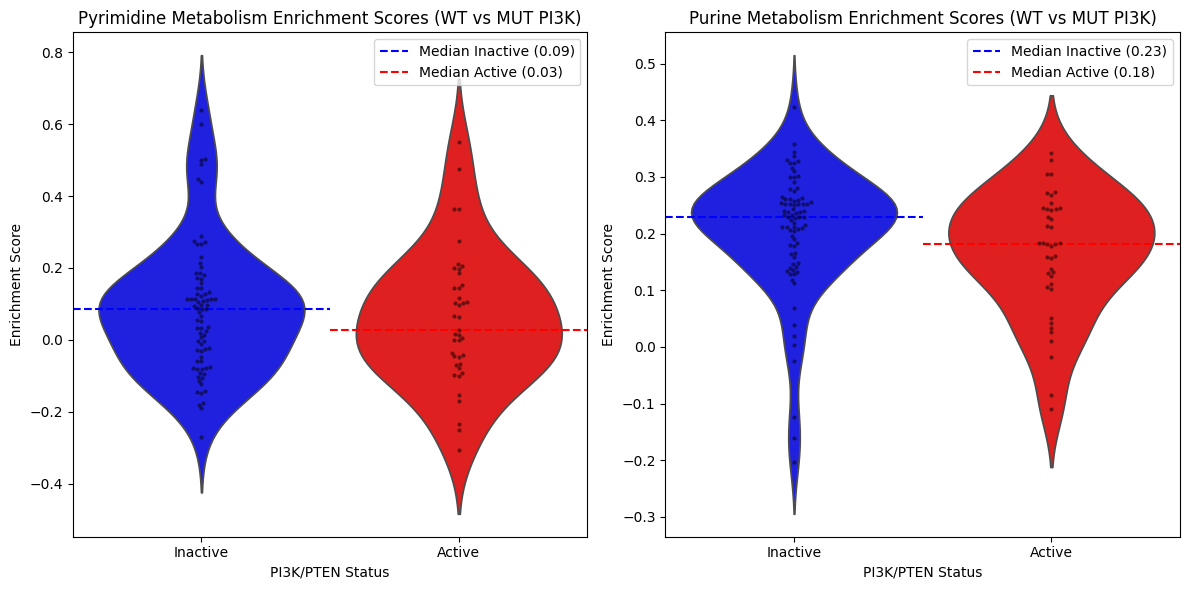

In [ ]:
pathways_to_plot = ['Pyrimidine Metabolism', 'Purine Metabolism']
plot_data = sspa_res_keep_cols[['PI3K'] + pathways_to_plot]
plot_data = plot_data.replace('WT', 'Inactive').replace('MUT', 'Active')

plot_data_melted = plot_data.melt(id_vars='PI3K', var_name='Pathway', value_name='Enrichment Score')

pi3k_order = ['Inactive', 'Active']

plt.figure(figsize=(12, 6))

# --- Pyrimidine Metabolism Plot ---
plt.subplot(1, 2, 1)
subset_data_pyr = plot_data_melted[plot_data_melted['Pathway'] == 'Pyrimidine Metabolism']
sns.violinplot(x='PI3K', y='Enrichment Score', data=subset_data_pyr, palette={'Active': 'red', 'Inactive': 'blue'}, hue='PI3K', legend=False, order=pi3k_order, inner=None)
sns.swarmplot(x='PI3K', y='Enrichment Score', data=subset_data_pyr, color='black', size=3, alpha=0.5, order=pi3k_order)

median_inactive_pyr = subset_data_pyr[subset_data_pyr['PI3K'] == 'Inactive']['Enrichment Score'].median()
median_active_pyr = subset_data_pyr[subset_data_pyr['PI3K'] == 'Active']['Enrichment Score'].median()

plt.axhline(y=median_inactive_pyr, color='blue', linestyle='--', label=f'Median Inactive ({median_inactive_pyr:.2f})', xmin=0.0, xmax=0.5) # xmin/xmax relative to subplot
plt.axhline(y=median_active_pyr, color='red', linestyle='--', label=f'Median Active ({median_active_pyr:.2f})', xmin=0.5, xmax=1.0)
plt.legend(loc='upper right')
plt.title('Pyrimidine Metabolism Enrichment Scores (WT vs MUT PI3K)')
plt.xlabel('PI3K/PTEN Status')
plt.ylabel('Enrichment Score')

# --- Purine Metabolism Plot ---
plt.subplot(1, 2, 2)
subset_data_pur = plot_data_melted[plot_data_melted['Pathway'] == 'Purine Metabolism']
sns.violinplot(x='PI3K', y='Enrichment Score', data=subset_data_pur, palette={'Active': 'red', 'Inactive': 'blue'}, hue='PI3K', legend=False, order=pi3k_order, inner=None)
sns.swarmplot(x='PI3K', y='Enrichment Score', data=subset_data_pur, color='black', size=3, alpha=0.5, order=pi3k_order)

median_inactive_pur = subset_data_pur[subset_data_pur['PI3K'] == 'Inactive']['Enrichment Score'].median()
median_active_pur = subset_data_pur[subset_data_pur['PI3K'] == 'Active']['Enrichment Score'].median()

plt.axhline(y=median_inactive_pur, color='blue', linestyle='--', label=f'Median Inactive ({median_inactive_pur:.2f})', xmin=0.0, xmax=0.5)
plt.axhline(y=median_active_pur, color='red', linestyle='--', label=f'Median Active ({median_active_pur:.2f})', xmin=0.5, xmax=1.0)
plt.legend(loc='upper right')
plt.title('Purine Metabolism Enrichment Scores (WT vs MUT PI3K)')
plt.xlabel('PI3K/PTEN Status')
plt.ylabel('Enrichment Score')

plt.tight_layout()
plt.savefig(os.path.join(save_path, 'CPTAC_Pyrimidine_Purine_Metabolism_Enrichment_Scores.svg'), bbox_inches='tight')
plt.show()

##t-tests

In [ ]:
metabolomics_pi3k[['PI3K']].value_counts()

,count
PI3K,
WT,80
MUT,41


In [ ]:
from scipy import stats

pathways = ['Pyrimidine Metabolism', 'Purine Metabolism']

for pathway in pathways:
    mut_scores = sspa_res_keep_cols[sspa_res_keep_cols['PI3K'] == 'MUT'][pathway].dropna()
    wt_scores = sspa_res_keep_cols[sspa_res_keep_cols['PI3K'] == 'WT'][pathway].dropna()

    # Perform Welch's t-test (assuming unequal variances)
    t_stat, p_value = stats.ttest_ind(wt_scores, mut_scores, equal_var=False)

    print(f"T-test for {pathway}:")
    print(f"  - T-statistic: {t_stat:.4f}")
    print(f"  - P-value: {p_value:.4f}")
    print("\n")

T-test for Pyrimidine Metabolism:
  - T-statistic: 0.7467
  - P-value: 0.4574


T-test for Purine Metabolism:
  - T-statistic: 1.9080
  - P-value: 0.0599


